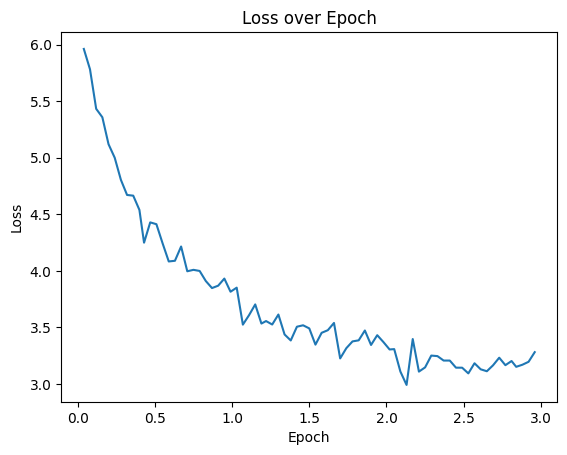

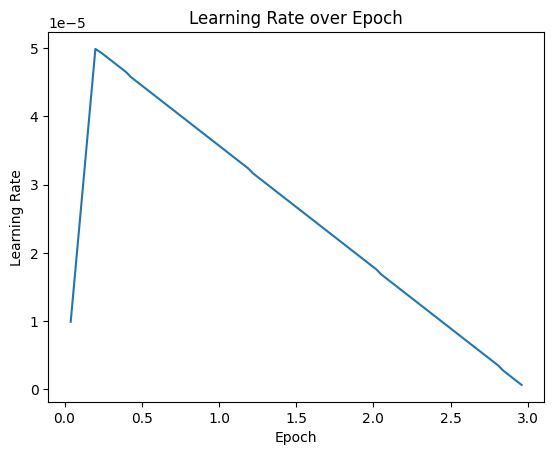

In [2]:
import ast
import re
import matplotlib.pyplot as plt

# 1) Read & split your file into pure dict-strings
raw_entries = []
with open('/cs/student/projects1/aibh/2024/acunning/Projects/Results/training_logs/log20k.txt', 'r') as f:
    for line in f:
        # find all occurrences of {...} in the line
        for chunk in re.findall(r'\{[^}]*\}', line):
            raw_entries.append(chunk)

# 2) Parse each chunk, safely falling back to eval()
data = []
for s in raw_entries:
    try:
        entry = ast.literal_eval(s)
    except (ValueError, SyntaxError):
        entry = eval(s)
    data.append(entry)

# 3) Extract your curves
epochs = [d['epoch'] for d in data]
losses = [d['loss'] for d in data]
lrs    = [d['learning_rate'] for d in data]

# 4) Plot Loss vs. Epoch
plt.figure()
plt.plot(epochs, losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epoch')
plt.show()

# 5) Plot LR vs. Epoch
plt.figure()
plt.plot(epochs, lrs)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate over Epoch')
plt.show()
